# 02 — 板块等权市场环境与南华商品指数

本 Notebook 展示板块组合等权的波动—相关性市场环境，并将南华商品指数按四类市场状态进行条件统计。

## 统计口径

- 每日先对每个板块内的有效品种对数收益等权平均，形成板块收益；成员首次通过40条最小观测门槛后，品种和新板块按六个月线性 ramp-in，并按当日实际有效权重归一化。
- 每个月末使用此前 90 个自然日的板块收益计算波动率和板块对绝对相关性；研究口径统一按每月 30 天计，即 3 个月 = 90 天。
- 只为已经完成的月份生成月末指标；行情停在月中时不生成该月指标。
- 状态阈值为此前 36 个完整月的严格滞后滚动中位数，状态从下一个交易日起生效；历史不足区间不参与结果。
- 南华商品指数不做起点归一化，按 252 个交易日年化；图 4 按各状态收益出现顺序连续累计，不显示时间。

In [1]:
# ruff: noqa: E402, E501
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config" / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

import cta_research
from cta_research import (
    INSUFFICIENT_HISTORY,
    REGIME_LABELS,
    build_sector_research_context,
    compute_regime_cumulative_returns,
    compute_series_regime_performance,
    plot_market_environment,
    plot_nhci_regimes,
    plot_regime_cumulative_returns,
)

assert Path(cta_research.__file__).resolve().is_relative_to((PROJECT_ROOT / "src").resolve())
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

Matplotlib is building the font cache; this may take a moment.


In [2]:
context = build_sector_research_context(PROJECT_ROOT / "config" / "config.yaml", PROJECT_ROOT)
config = context.config
monthly_regimes = context.monthly_regimes
summary = pd.Series(
    {
        "商品数据起止": f"{context.dominant_prices['date'].min().date()} — {context.dominant_prices['date'].max().date()}",
        "南华商品指数起止": f"{context.nhci.index.min().date()} — {context.nhci.index.max().date()}",
        "映射板块数": context.unramped_sector_returns.shape[1],
        "有效品种数": context.daily_returns.shape[1],
        "有效市场状态月份": int(monthly_regimes["regime"].ne(INSUFFICIENT_HISTORY).sum()),
    },
    name="value",
)
display(summary.to_frame())

,value
商品数据起止,2011-07-01 — 2026-08-03
南华商品指数起止,2011-07-01 — 2026-07-31
映射板块数,11
有效品种数,89
有效市场状态月份,143


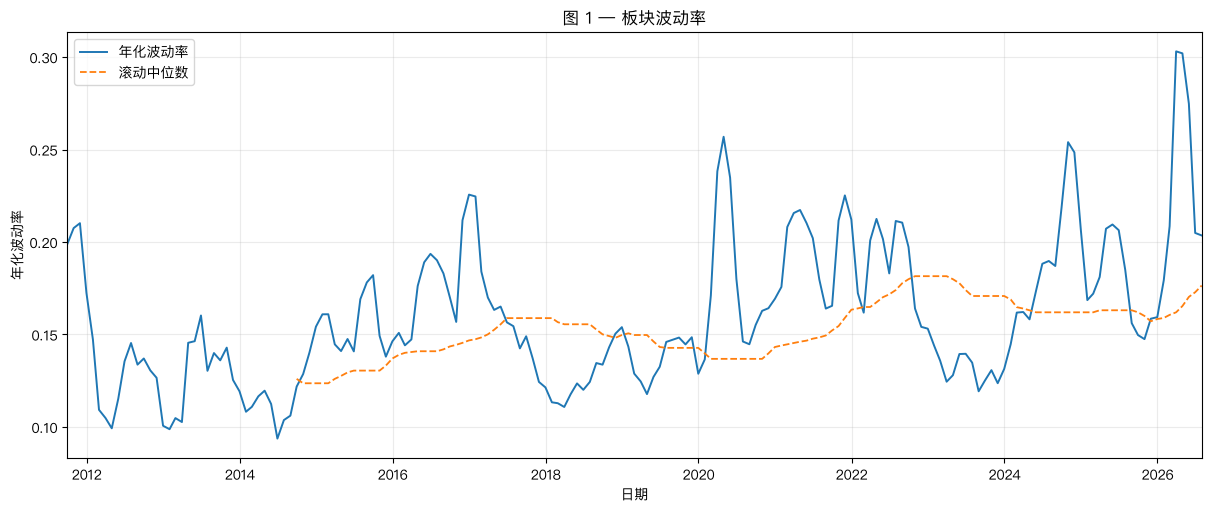

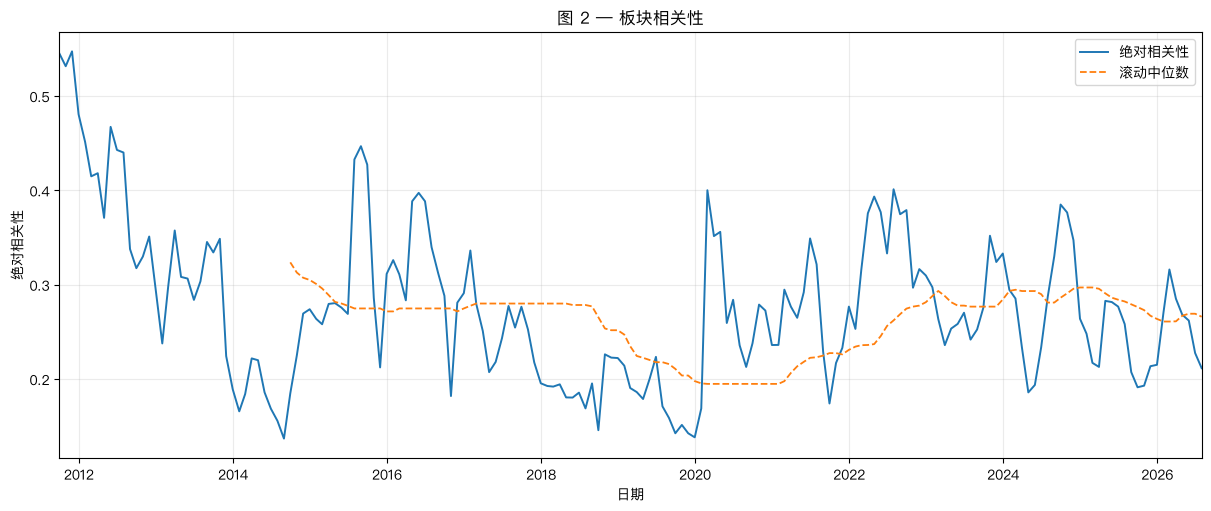

In [3]:
figure_1 = plot_market_environment(
    monthly_regimes,
    "volatility",
    "volatility_threshold",
    "图 1 — 板块波动率",
    "年化波动率",
)
display(figure_1)
figure_1.savefig(FIGURES_DIR / "figure_1_volatility.png", dpi=150, bbox_inches="tight")
plt.close(figure_1)

figure_2 = plot_market_environment(
    monthly_regimes,
    "correlation",
    "correlation_threshold",
    "图 2 — 板块相关性",
    "绝对相关性",
)
display(figure_2)
figure_2.savefig(FIGURES_DIR / "figure_2_correlation.png", dpi=150, bbox_inches="tight")
plt.close(figure_2)

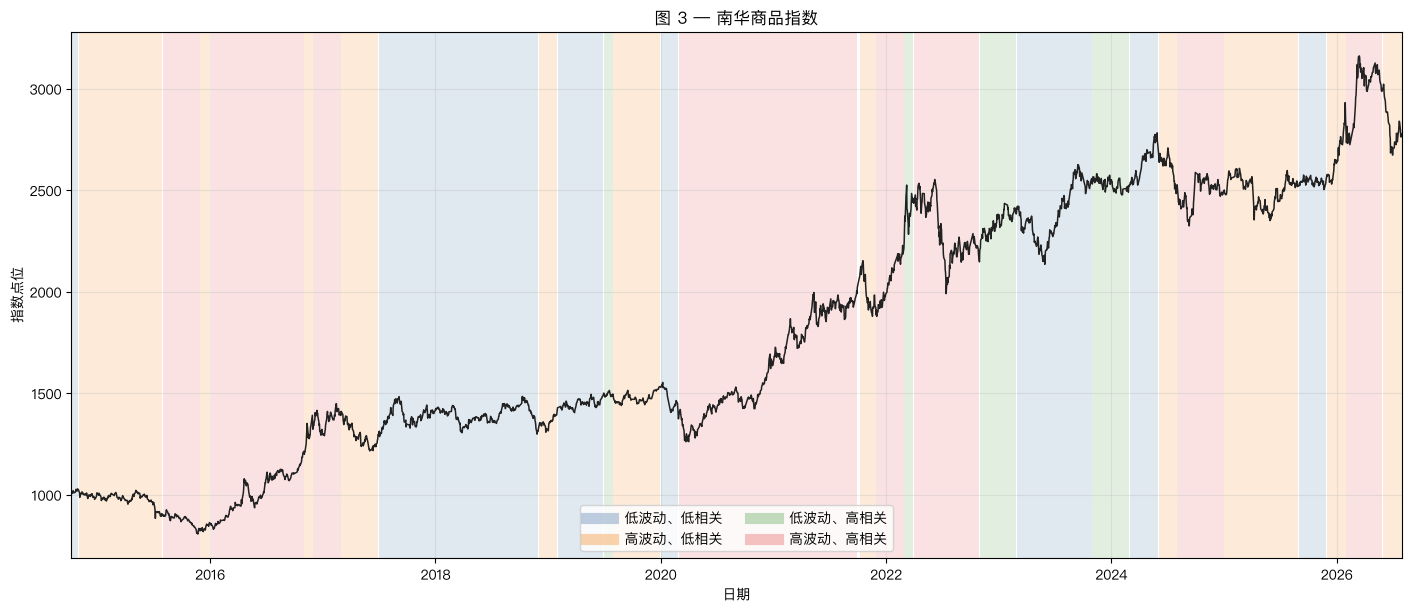

,样本数,年化收益,夏普比率
低波动、低相关,781,4.05%,0.37
高波动、低相关,786,-2.43%,-0.10
低波动、高相关,206,28.81%,1.63
高波动、高相关,1101,18.85%,1.06


In [4]:
figure_3 = plot_nhci_regimes(context.nhci, context.stages)
display(figure_3)
figure_3.savefig(FIGURES_DIR / "figure_3_nhci_regimes.png", dpi=150, bbox_inches="tight")
plt.close(figure_3)

nhci_metrics = compute_series_regime_performance(
    context.nhci, context.daily_regimes, periods_per_year=config["annualization_days"]
)
nhci_table = nhci_metrics[["n_observations", "annualized_return", "annualized_sharpe"]].copy()
nhci_table.index = [REGIME_LABELS[regime] for regime in nhci_table.index]
nhci_table.columns = ["样本数", "年化收益", "夏普比率"]
display(nhci_table.style.format({"年化收益": "{:.2%}", "夏普比率": "{:.2f}"}))

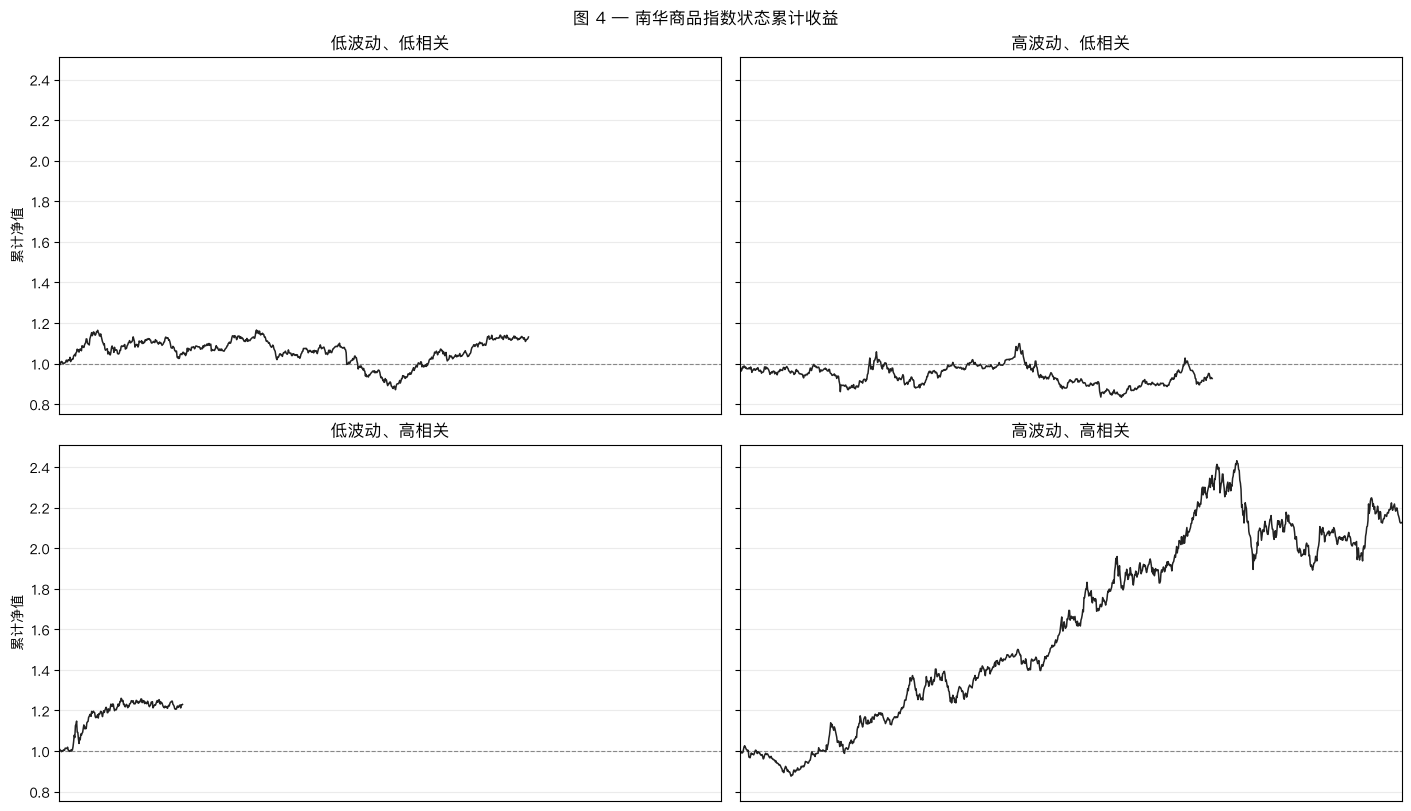

In [5]:
cumulative_returns = compute_regime_cumulative_returns(context.nhci, context.daily_regimes)
figure_4 = plot_regime_cumulative_returns(cumulative_returns, sharex=True, sharey=True)
display(figure_4)
figure_4.savefig(FIGURES_DIR / "figure_4_regime_returns.png", dpi=150, bbox_inches="tight")
plt.close(figure_4)

In [6]:
appendix = (
    "<details><summary>数据覆盖、板块映射与排除诊断</summary>"
    + context.coverage.head(8).to_html(index=False)
    + context.coverage.tail(8).to_html(index=False)
    + pd.DataFrame({"unmapped_symbol": context.unmapped_symbols}).to_html(index=False)
    + monthly_regimes[["volatility", "correlation", "n_sectors", "n_pairs", "regime"]].tail(12).to_html()
    + "</details>"
)
display(HTML(appendix))

underlying_symbol,start_date,end_date,rows
A,2011-07-01,2026-08-03,3665
J,2011-07-01,2026-08-03,3665
L,2011-07-01,2026-08-03,3665
M,2011-07-01,2026-08-03,3665
P,2011-07-01,2026-08-03,3665
PB,2011-07-01,2026-08-03,3665
RB,2011-07-01,2026-08-03,3665
RO,2011-07-01,2013-05-15,452
underlying_symbol,start_date,end_date,rows
BZ,2025-07-08,2026-08-03,261
